In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### HW_04

`Input/customer_data.csv`를 분석하여 다음 질문에 답하시오.

- Missing Value가 있는 Column Name과 각각의 Missing Value 수를 적으시오.
- 완전히 동일한 Duplicate Row는 몇 개인지 적으시오.
- `Age`가 0보다 작거나 100보다 큰 Row의 `CustomerID`를 모두 적으시오.
- `Gender`에 저장되어 있는 서로 다른 값을 모두 적으시오.
- `Income`의 Mean과 Median을 각각 적으시오.

답만 제출하시오.

In [8]:
customer_data = pd.read_csv('../Input/customer_data.csv')

In [11]:
print(customer_data.isnull().sum())
display(customer_data[customer_data.isnull().any(axis=1)])

CustomerID    0
Age           4
Gender        0
City          0
Income        4
Purchase      0
dtype: int64


,CustomerID,Age,Gender,City,Income,Purchase
5,1006,NaN,Male,Incheon,61675.0,466.0
12,1013,41.0,Male,Seoul,NaN,395.0
23,1024,NaN,Male,Daegu,41420.0,660.0
44,1045,20.0,Female,Busan,NaN,364.0
71,1072,NaN,Female,Daegu,34871.0,553.0
98,1099,62.0,Female,Daegu,NaN,637.0
120,1121,NaN,Female,Seoul,28791.0,504.0
150,1151,54.0,Male,Busan,NaN,381.0


In [13]:
print(customer_data.duplicated().sum())

3


In [16]:
display(customer_data[(customer_data["Age"] < 0) | (customer_data["Age"] > 100)])

,CustomerID,Age,Gender,City,Income,Purchase
30,1031,-5.0,Female,Gwangju,58483.0,407.0
80,1081,150.0,Male,Busan,36578.0,623.0


In [17]:
customer_data["Gender"].value_counts()

Female    107
Male       93
male        1
M           1
female      1
Name: Gender, dtype: int64

In [21]:
display(customer_data.describe())
print(f"Mean income: {customer_data['Income'].mean()}")
print(f"Median income: {customer_data['Income'].median()}")

,CustomerID,Age,Income,Purchase
count,203.000000,199.000000,199.000000,203.000000
mean,1099.768473,45.130653,46492.814070,531.266010
std,57.812522,18.027281,34749.030516,354.261187
min,1001.000000,-5.000000,4631.000000,82.000000
25%,1050.500000,31.000000,35674.000000,395.000000
50%,1099.000000,44.000000,45285.000000,512.000000
75%,1149.500000,59.000000,54156.500000,615.500000
max,1200.000000,150.000000,500000.000000,5000.000000


Mean income: 46492.81407035176
Median income: 45285.0


### HW_05

`Input/california_housing.csv`의 `AveOccup`를 분석하여 다음 질문에 답하시오.

- `AveOccup`의 Mean과 Median을 각각 적으시오.
- `AveOccup`의 Histogram을 `bins=30`으로 그렸을 때 가장 많은 Data가 분포하는 구간을 적으시오.
- `AveOccup`의 $Q_1$, $Q_3$, IQR을 각각 적으시오.
- IQR 기준으로 계산한 Outlier의 수를 적으시오.
- `AveOccup`의 가장 큰 값과 해당 Row의 `MedHouseVal`을 적으시오.

답만 제출하시오.

In [23]:
california_housing_data = pd.read_csv('../Input/california_housing.csv')
AveOccup = california_housing_data['AveOccup']

In [24]:
display(AveOccup.describe())
print(f"Mean AveOccup: {AveOccup.mean()}")
print(f"Median AveOccup: {AveOccup.median()}")


count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

Mean AveOccup: 3.070655159436382
Median AveOccup: 2.818115654360196


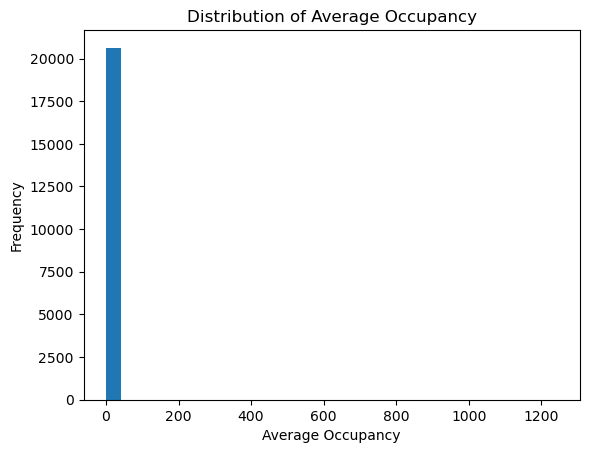

In [54]:
plt.hist(AveOccup, bins=30)
plt.title('Distribution of Average Occupancy')
plt.xlabel('Average Occupancy')
plt.ylabel('Frequency')
plt.show()

In [56]:
AveOccup.quantile([0.25, 0.5, 0.75])

Q1 = AveOccup.quantile(0.25)
Q3 = AveOccup.quantile(0.75)
IQR = Q3 - Q1

# Outlier 판단 범위 계산
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 범위를 벗어난 data 확인
outliers = california_housing_data[
    (california_housing_data["AveOccup"] < lower) |
    (california_housing_data["AveOccup"] > upper)
]

outliers_count = outliers.shape[0]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Outliers Count:", outliers_count)
display(outliers)

Q1: 2.4297411475535755
Q3: 3.2822609242736216
IQR: 0.8525197767200461
Lower Bound: 1.1509614824735064
Upper Bound: 4.5610405893536905
Outliers Count: 711


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
89,1.2434,52.0,2.929412,0.917647,396.0,4.658824,37.80,-122.27,5.00001
91,0.8668,52.0,2.443182,0.988636,904.0,10.272727,37.80,-122.28,1.37500
92,0.7500,52.0,2.823529,0.911765,191.0,5.617647,37.80,-122.28,1.62500
200,3.0257,52.0,4.046948,1.009390,994.0,4.666667,37.78,-122.23,0.80800
270,3.8750,33.0,3.021277,0.659574,575.0,12.234043,37.78,-122.18,2.25000
...,...,...,...,...,...,...,...,...,...
20353,5.0066,12.0,3.800000,1.466667,69.0,4.600000,34.13,-119.05,2.75000
20393,5.7560,16.0,6.117493,1.026110,2007.0,5.240209,34.22,-118.88,3.02700
20513,2.6250,34.0,5.597403,1.103896,391.0,5.077922,38.67,-121.63,2.25000
20527,1.4653,7.0,3.525794,1.017857,4479.0,8.886905,38.54,-121.79,3.10000


In [63]:
california_housing_data.sort_values(by="AveOccup", ascending=False).head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.546


### HW_06

`Input/california_housing.csv`를 분석하여 다음 질문에 답하시오.

- `MedHouseVal`을 제외한 Variable 중 `MedHouseVal`과 가장 높은 Positive Correlation을 가지는 Variable Name을 적으시오.
- 위 Variable과 `MedHouseVal` 사이의 Correlation 값을 소수점 셋째 자리까지 적으시오.
- `MedHouseVal`과 가장 높은 Negative Correlation을 가지는 Variable Name을 적으시오.
- 위 Variable과 `MedHouseVal` 사이의 Correlation 값을 소수점 셋째 자리까지 적으시오.
- `AveRooms`와 `AveBedrms` 사이의 Correlation 값을 소수점 셋째 자리까지 적으시오.

답만 제출하시오.

In [52]:
# display(california_housing_data.corr(numeric_only=True))
display(california_housing_data.corr())

display(california_housing_data.corr()["MedHouseVal"].sort_values(ascending=False))
display(california_housing_data.corr()["MedHouseVal"])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

MedInc         0.688075
HouseAge       0.105623
AveRooms       0.151948
AveBedrms     -0.046701
Population    -0.024650
AveOccup      -0.023737
Latitude      -0.144160
Longitude     -0.045967
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

In [53]:
california_housing_data["AveRooms"].corr(california_housing_data["AveBedrms"])

0.8476213257130455